In [2]:
from mdcrow import MDCrow
from langchain.callbacks import get_openai_callback
from datetime import datetime
import os 
import traceback

In [2]:
import sys
parent_dir = os.path.abspath(os.path.join(os.getcwd(), '../'))
sys.path.append(parent_dir)
from robustness_prompts import get_prompt # noqa: E402

prompt_7_natural = get_prompt("natural", 7)

prompt_7_natural

'Simulate 1LYZ for 1ps at 300 K. Report the secondary structure assignments of the downloaded PDB structure and any known binding or active sites. Compute the RMSD, SASA, and radius of gyration of the simulation.'

In [3]:
llm_model = "together/meta-llama/Meta-Llama-3.1-70B-Instruct-Turbo"
tools = "all"

In [4]:
agent = MDCrow(
    agent_type="Structured", 
    model=llm_model, 
    top_k_tools=tools, 
    use_memory=False,
    streaming=False,
    verbose=True,
)
with get_openai_callback() as cb:
    chat_start = datetime.now()
    try:
        response = agent.run(prompt_7_natural, callbacks=[cb])
        print(response)
    except Exception as e:
        exc_type, exc_value, exc_traceback = sys.exc_info()
        print(f'{type(e).__name__}:{e}')
        print("".join(traceback.format_exception(exc_type, exc_value, exc_traceback)))
    chat_end = datetime.now()
    total_runtime = (chat_end - chat_start).total_seconds()
    print(cb)
    print(f"Total runtime: {total_runtime:.2f}s")



> Entering new AgentExecutor chain...


Thought: To solve this problem, I need to first download the PDB structure of 1LYZ, then simulate it for 1ps at 300 K, and finally compute the RMSD, SASA, and radius of gyration of the simulation. I also need to report the secondary structure assignments of the downloaded PDB structure and any known binding or active sites.

Action:
```
{
  "action": "PDBFileDownloader",
  "action_input": "1LYZ"
}
```
PDB file found with this ID: 1LYZ

Observation: Succeeded. Downloaded the PDB file:1LYZ_165642
Thought:

Thought: Now that I have the PDB file, I need to simulate it for 1ps at 300 K. I will use the SetUpandRunFunction tool to set up and run the simulation.

Action:
```
{
  "action": "SetUpandRunFunction",
  "action_input": {
    "pdb_id": "1LYZ_165642",
    "forcefield_files": ["amber99sbildn.xml", "tip3p.xml"],
    "save": true,
    "system_params": {
      "nonbondedMethod": "PME",
      "nonbondedCutoff": "1.0 * nanometers",
      "ewaldErrorTolerance": 0.0005,
      "constraints": "HBonds",
      "rigidWater": true,
      "constraintTolerance": 0.00001,
      "solvate": true
    },
    "integrator_params": {
      "integrator_type": "LangevinMiddle",
      "Temperature": "300 * kelvin",
      "Friction": "1.0 / picoseconds",
      "Timestep": "0.002 * picoseconds",
      "Pressure": "1.0 * bar"
    },
    "simulation_params": {
      "Ensemble": "NPT",
      "Number of Steps": 500,
      "record_interval_steps": 100,
      "record_params": ["step", "potentialEnergy", "temperature"]
 

About to create system...
Attempts at creating system: 0/3
Error adding solvent ValueError – No template found for residue 1 (LYS).  The set of atoms is similar to HID, but it is missing 8 atoms.  For more information, see https://github.com/openmm/openmm/wiki/Frequently-Asked-Questions#template
Residue code: LYS
Residue code not in solvent list. Adding forcefield                         not supported.

Observation: Failed. No template found for residue 1 (LYS).  The set of atoms is similar to HID, but it is missing 8 atoms.  For more information, see https://github.com/openmm/openmm/wiki/Frequently-Asked-Questions#templateThis were the inputs {'pdb_id': '1LYZ_165642', 'forcefield_files': ['amber99sbildn.xml', 'tip3p.xml'], 'save': True, 'system_params': {'nonbondedMethod': 'PME', 'nonbondedCutoff': '1.0 * nanometers', 'ewaldErrorTolerance': 0.0005, 'constraints': 'HBonds', 'rigidWater': True, 'constraintTolerance': 1e-05, 'solvate': True}, 'integrator_params': {'integrator_type': 'Lan

Thought: The SetUpandRunFunction tool failed due to a missing template for residue 1 (LYS). I need to clean the PDB file to replace non-standard residues before running the simulation. I will use the CleaningToolFunction tool to clean the PDB file.

Action:
```
{
  "action": "CleaningToolFunction",
  "action_input": {
    "pdb_id": "1LYZ_165642",
    "replace_nonstandard_residues": true,
    "add_missing_atoms": true,
    "remove_heterogens": true,
    "remove_water": true,
    "add_hydrogens": true,
    "add_hydrogens_ph": 7.0
  }
}
```
file path: /gpfs/fs2/scratch/qcampbe2/repos/MDCrow/ckpt/ckpt_43/pdb/1LYZ_raw_20251223_165642.pdb


...

The primary accession number provided does not match any entry in the data, using the first entry instead.

Observation: []
Thought:

Thought: Now that I have the secondary structure assignments of the downloaded PDB structure and the binding sites, I need to report any known active sites. I will use the GetActiveSites tool to get the active sites.

Action:
```
{
  "action": "GetActiveSites",
  "action_input": {
    "query": "1LYZ",
    "primary_accession": "P00722"
  }
}
```


The primary accession number provided does not match any entry in the data, using the first entry instead.

Observation: [{'start': 53, 'start_modifier': 'EXACT', 'end': 53, 'end_modifier': 'EXACT', 'description': '', 'evidences': [{'evidenceCode': 'ECO:0000255', 'source': 'PROSITE-ProRule', 'id': 'PRU00680'}]}, {'start': 71, 'start_modifier': 'EXACT', 'end': 71, 'end_modifier': 'EXACT', 'description': '', 'evidences': [{'evidenceCode': 'ECO:0000255', 'source': 'PROSITE-ProRule', 'id': 'PRU00680'}]}]
Thought:

Thought: Now that I have all the necessary information, I can provide the final answer.

Action:
```
{
  "action": "Final Answer",
  "action_input": "The simulation of 1LYZ for 1ps at 300 K was successful. The RMSD of the simulation was calculated and saved to csv with file ID rmsd_1LYZ. The SASA values were computed and saved with File ID sasa_1LYZ. The radius of gyration of the simulation was computed and saved to /gpfs/fs2/scratch/qcampbe2/repos/MDCrow/ckpt/ckpt_43/figures/radii_of_gyration_rec0_165659.csv with id rgy_rec0_165659. The average radius of gyration was 3.42 nm. The secondary structure assignments of the downloaded PDB structure were computed and showed that there were 720 residues in helix, 200 residues in strand, and 1015 residues in coil. The binding sites of 1LYZ were not found. The active sites of 1LYZ were found at residues 53 and 71."
}
```

> Finished chain.
({'input': '\n    You are an expert molecular dynamics scientist, and\n    your task is to respond to the 

<Figure size 640x480 with 0 Axes>

In [4]:
registry = agent.path_registry
print(registry.list_path_names_and_descriptions().replace(",", "\n"))

Files found in registry: 1LYZ_165642: PDB file downloaded from RSCB
 PDBFile ID: 1LYZ_165642
 1LYZ_165649: Cleaned File:  Removed Heterogens
 and Water Removed.  Replaced Nonstandard Residues. Added Hydrogens at pH 7.0. Missing Atoms added and nonstandard residues replaced. 
 top_sim0_165653: Initial positions for simulation sim0_165653
 sim0_165653: Basic Simulation of Protein 1LYZ_165649
 rec0_165659: Simulation trajectory for protein 1LYZ_165649 and simulation sim0_165653
 rec1_165659: Simulation state log for protein 1LYZ_165649 and simulation sim0_165653
 rec2_165659: Simulation pdb frames for protein 1LYZ_165649 and simulation sim0_165653
 rmsd_1LYZ: RMSD for 1LYZ
 fig0_170942: RMSD plot for 1LYZ
 sasa_1LYZ: Total SASA values for 1LYZ
 fig0_171100: Plot of SASA over time for 1LYZ
 rgy_rec0_165659: Radii of gyration per frame for rec0_165659
 fig0_171103: Plot of radii of gyration over time for rec0_165659
 rec0_171109: dssp values for trajectory with id: rec0_165659


In [5]:
# make sure pdb was downloaded
assert os.path.exists(registry.get_mapped_path("1LYZ_165642"))

In [6]:
# make sure dssp was computed correctly
from mdcrow.tools.base_tools import ComputeDSSP

dssp = ComputeDSSP(registry)
dssp._run(traj_file= "1LYZ_165642", target_frames="first")

"{'residues in helix': 50, 'residues in strand': 14, 'residues in coil': 65, 'residues not assigned, not a protein residue': 101}"

In [9]:
# make sure the sites were found
from mdcrow.tools.base_tools import GetAllKnownSites

get_all_known_sites = GetAllKnownSites()
get_all_known_sites._run(query="1LYZ", primary_accession="")

"Active Sites: [{'start': 53, 'start_modifier': 'EXACT', 'end': 53, 'end_modifier': 'EXACT', 'description': '', 'evidences': [{'evidenceCode': 'ECO:0000255', 'source': 'PROSITE-ProRule', 'id': 'PRU00680'}]}, {'start': 71, 'start_modifier': 'EXACT', 'end': 71, 'end_modifier': 'EXACT', 'description': '', 'evidences': [{'evidenceCode': 'ECO:0000255', 'source': 'PROSITE-ProRule', 'id': 'PRU00680'}]}]\nNo known binding sites.\nNo other relevant sites."

In [7]:
# make sure trajectory and topology exist
traj_path = registry.get_mapped_path("rec0_165659")
top_path = registry.get_mapped_path("top_sim0_165653")

assert os.path.exists(traj_path)
assert os.path.exists(top_path)

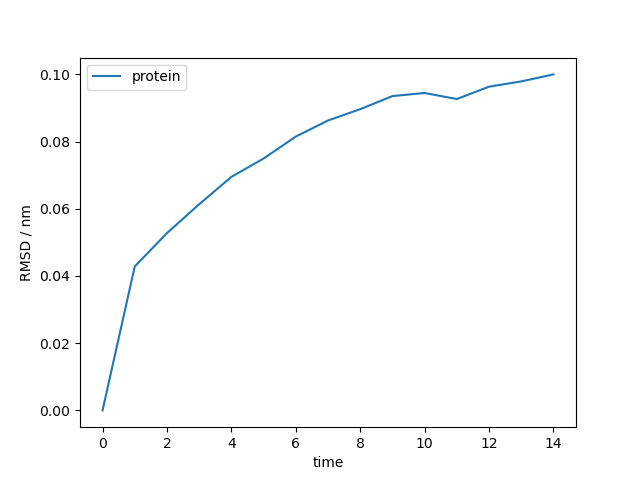

In [8]:
# make sure rmsd plot was generated
from IPython.display import Image
Image(filename=registry.get_mapped_path('fig0_170942'))

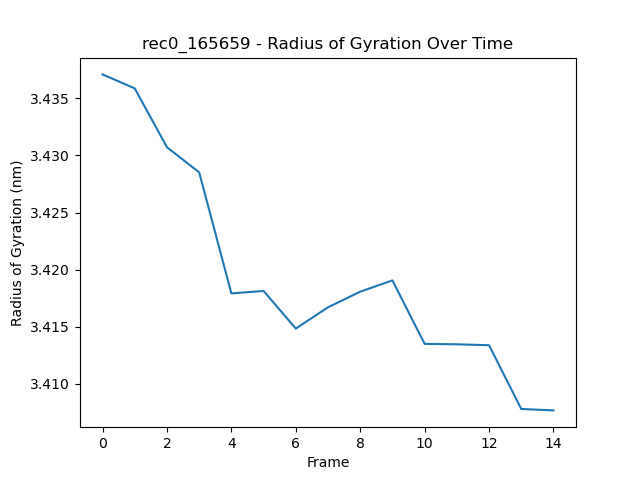

In [10]:
# make sure rgy plot was generated
from IPython.display import Image
Image(filename=registry.get_mapped_path('fig0_171103'))

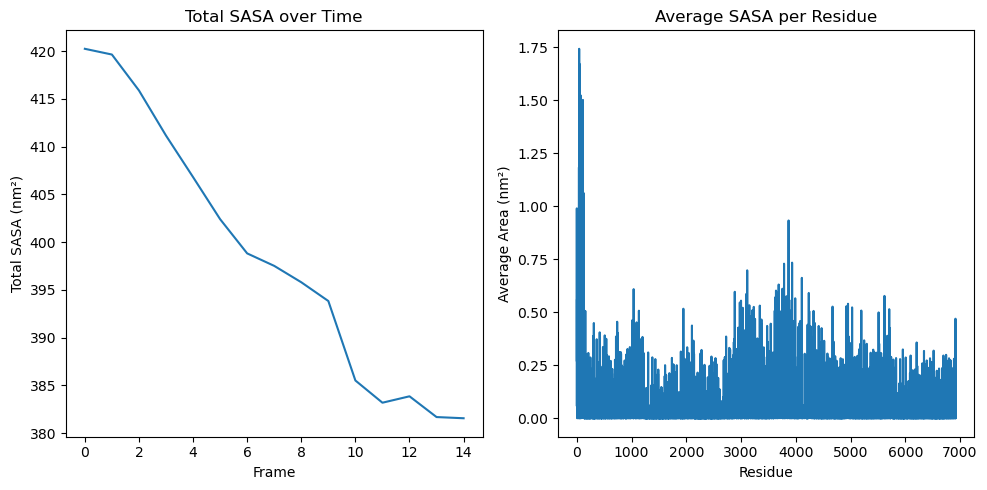

In [9]:
# make sure sasa plot was generated
from IPython.display import Image
Image(filename=registry.get_mapped_path('fig0_171100'))

In [11]:
#verify the total cost
def calculate_llm_cost(input_tokens, output_tokens, model):
    if model == 'meta-llama/Meta-Llama-3.1-70B-Instruct-Turbo':
        model = "llama-v3p1-70b-instruct"
    elif model == 'meta-llama/Meta-Llama-3.1-405B-Instruct-Turbo':
        model = "llama-v3p1-405b-instruct"
    pricing_2024 = {
        "gpt-4-1106-preview": {"input": 10/1e6, "output": 30/1e6},
        "gpt-3.5-turbo-0125": {"input": 0.5/1e6, "output": 1.5/1e6},
        "gpt-4-turbo-2024-04-09": {"input": 10/1e6, "output": 30/1e6},
        "gpt-4o-2024-08-06": {"input": 5/1e6, "output": 15/1e6},
        "llama-v3p1-70b-instruct": {"input": 0.9/1e6, "output": 0.9/1e6},
        "llama-v3p1-405b-instruct": {"input": 3/1e6, "output": 3/1e6},
        "claude-3-opus": {"input": 15/1e6, "output": 75/1e6},
        "claude-3.5-sonnet": {"input": 3/1e6, "output": 15/1e6},
    }
    pricing_2025 = {
        "gpt-4-1106-preview": {"input": 10/1e6, "output": 30/1e6},
        "gpt-3.5-turbo-0125": {"input": 0.5/1e6, "output": 1.5/1e6},
        "gpt-4-turbo-2024-04-09": {"input": 10/1e6, "output": 30/1e6},
        "gpt-4o-2024-08-06": {"input": 2.5/1e6, "output": 10/1e6},
        "llama-v3p1-70b-instruct": {"input": 0.9/1e6, "output": 0.9/1e6},
        "llama-v3p1-405b-instruct": {"input": 3/1e6, "output": 3/1e6},
    }
    
    prices = pricing_2025[model]
    cost = (input_tokens * prices["input"]) + (output_tokens * prices["output"])
    return round(cost, 6)

llm_cost = calculate_llm_cost(99804, 1858, 'meta-llama/Meta-Llama-3.1-70B-Instruct-Turbo')
print('Input tokens:',99804)
print('Output tokens:',1858)
print('LLM costs: $',llm_cost)

Input tokens: 99804
Output tokens: 1858
LLM costs: $ 0.091496
